In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Load dataset
df = pd.read_csv("../data/processed/features_v2.csv")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values("date")

# Train/test split (same as Stage 3)
split_date = df['date'].quantile(0.8)

train = df[df['date'] < split_date].copy()
test  = df[df['date'] >= split_date].copy()


In [15]:
target = "points"

drop_cols = [
    "raceId", "driverId", "constructorId",
    "date",
    "positionOrder",  # other targets removed
    "avgLapTime_s",
    "points"
]

features = [col for col in df.columns if col not in drop_cols]

X_train = train[features]
X_test  = test[features]

y_train = train[target]
y_test  = test[target]


In [16]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

preds = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("R2:", r2_score(y_test, preds))


MAE: 3.1714359837231942
R2: 0.5873552739997292


In [17]:
test_results = test.copy()
test_results["prediction"] = preds
test_results["error"] = test_results["points"] - test_results["prediction"]
test_results["abs_error"] = np.abs(test_results["error"])


is_DNF
False    3.171436
Name: abs_error, dtype: float64


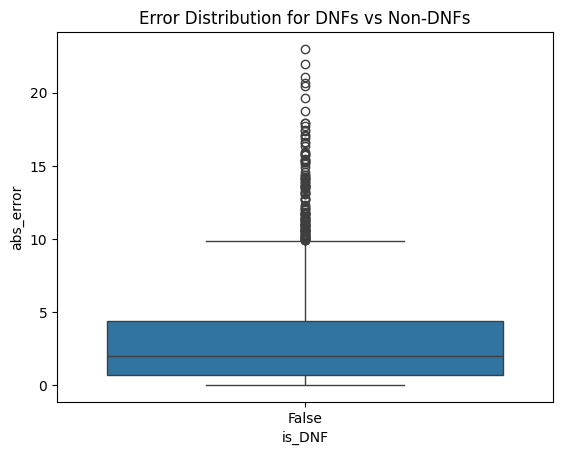

In [18]:
# Define DNF as finishing outside top 20 (adjust if needed)
test_results["is_DNF"] = test_results["positionOrder"] > 20

dnf_errors = test_results.groupby("is_DNF")["abs_error"].mean()
print(dnf_errors)


sns.boxplot(x="is_DNF", y="abs_error", data=test_results)
plt.title("Error Distribution for DNFs vs Non-DNFs")
plt.show()


circuitId
20    4.596247
18    4.552527
5     4.186078
80    3.907990
73    3.828504
78    3.805027
3     3.672508
76    3.650239
14    3.492804
21    3.445323
Name: abs_error, dtype: float64


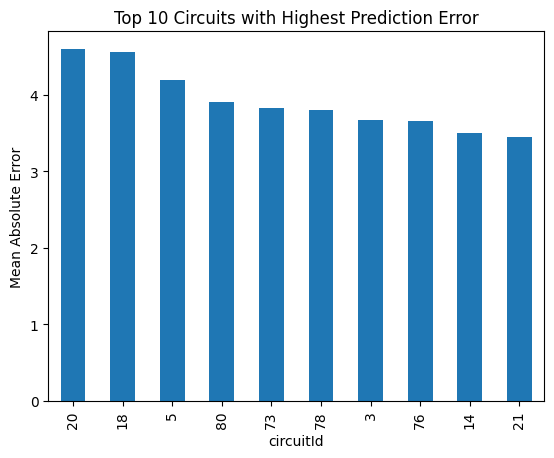

In [19]:
circuit_errors = (
    test_results
    .groupby("circuitId")["abs_error"]
    .mean()
    .sort_values(ascending=False)
)

print(circuit_errors.head(10))

circuit_errors.head(10).plot(kind="bar")
plt.title("Top 10 Circuits with Highest Prediction Error")
plt.ylabel("Mean Absolute Error")
plt.show()


                      feature  importance
7    constructor_points_roll5    0.279550
5        constructor_form_avg    0.270895
2                        grid    0.192024
1                        year    0.055488
4             driver_form_avg    0.053250
8   driver_circuit_avg_finish    0.047784
3                pitStopCount    0.038886
0                   circuitId    0.032483
6           driver_experience    0.023116
9          circuitType_street    0.003775
12                     era_v8    0.001779
11                 era_hybrid    0.000971
10          era_ground_effect    0.000000


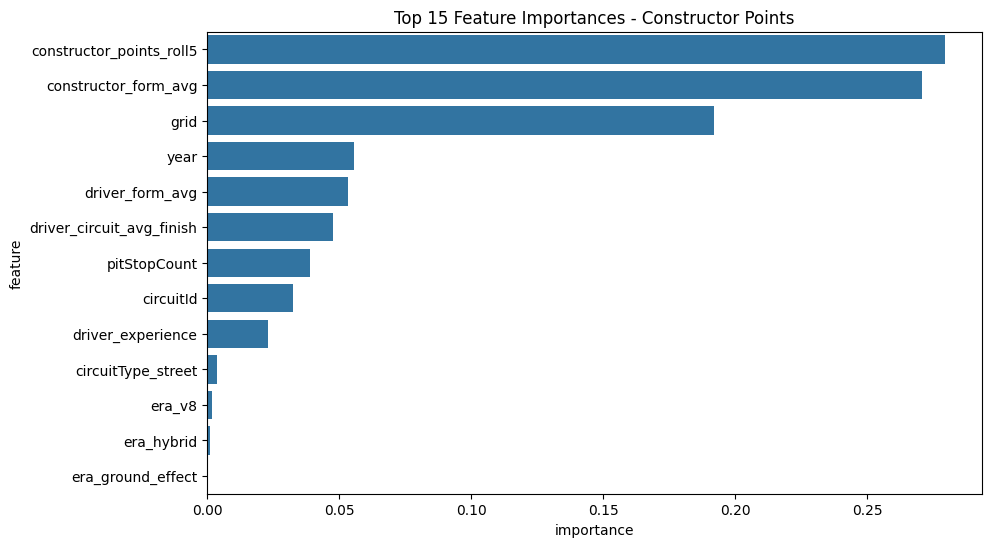

In [20]:
importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values("importance", ascending=False)

print(feature_importance_df.head(15))


top_n = 15

plt.figure(figsize=(10,6))
sns.barplot(
    x="importance",
    y="feature",
    data=feature_importance_df.head(top_n)
)
plt.title("Top 15 Feature Importances - Constructor Points")
plt.show()


In [21]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


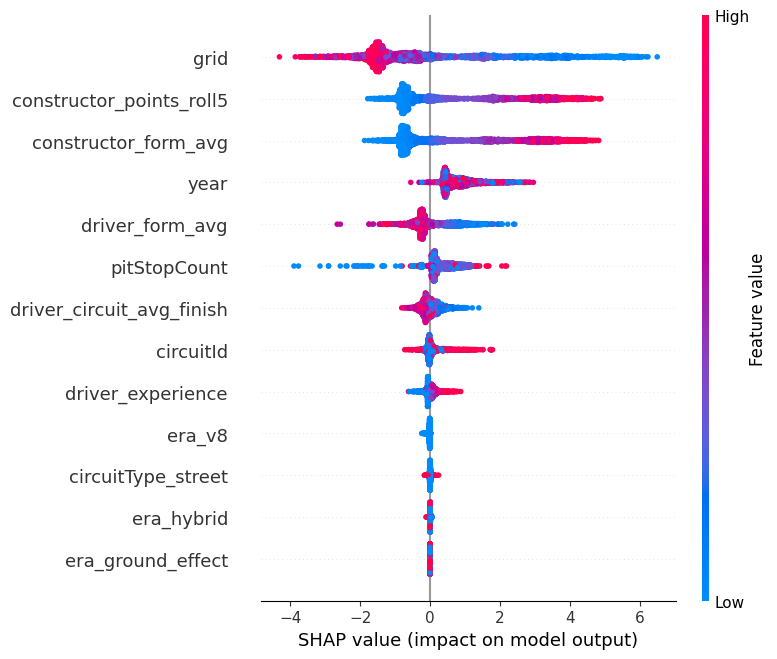

In [22]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)


In [23]:
feature_importance_df.tail(10)

,feature,importance
1,year,0.055488
4,driver_form_avg,0.053250
8,driver_circuit_avg_finish,0.047784
3,pitStopCount,0.038886
0,circuitId,0.032483
6,driver_experience,0.023116
9,circuitType_street,0.003775
12,era_v8,0.001779
11,era_hybrid,0.000971
10,era_ground_effect,0.000000


In [24]:
low_importance_features = feature_importance_df.tail(5)["feature"].tolist()

reduced_features = [f for f in features if f not in low_importance_features]

rf.fit(train[reduced_features], y_train)
new_preds = rf.predict(test[reduced_features])

print("New R2:", r2_score(y_test, new_preds))


New R2: 0.587234913889586


In [25]:
print(features)


['circuitId', 'year', 'grid', 'pitStopCount', 'driver_form_avg', 'constructor_form_avg', 'driver_experience', 'constructor_points_roll5', 'driver_circuit_avg_finish', 'circuitType_street', 'era_ground_effect', 'era_hybrid', 'era_v8']
